In [1]:
%%capture
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects  # Add this import
import matplotlib.patheffects as mpe


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib.patches import Patch


In [3]:
from matplotlib import font_manager as fm
from pathlib import Path as _Path

_font_candidates = (
    _Path.home() / 'fonts' / 'ARIAL.TTF',
    _Path('/home/arseniy/fonts/ARIAL.TTF'),
    _Path('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'),
    _Path('/usr/share/fonts/truetype/msttcorefonts/arial.ttf'),
    _Path('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'),
    _Path('/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf'),
)

_font_path = next((p for p in _font_candidates if p.is_file()), None)
if _font_path is not None:
    fm.fontManager.addfont(str(_font_path))
    _font_name = fm.FontProperties(fname=str(_font_path)).get_name()
else:
    _font_name = 'DejaVu Sans'

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [_font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['font.size'] = 12
print(f'Using font: {_font_name}' + (f' ({_font_path})' if _font_path else ''))


Using font: Arial (/home/arseniy/fonts/ARIAL.TTF)


In [4]:
pd.set_option('display.max_rows', None)


## First screening stage for the dopants

In [5]:
import mendeleev as md
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
from pathlib import Path


VISUALIZING METALLIC RADII (Periodic Table Order)
Li metallic radius: 152 pm
Compatibility criterion: 0.85×r_Li < r_dopant < 1.15×r_Li
  = 129.2 pm < r_dopant < 174.8 pm
  = -22.8 pm < (r_dopant - r_Li) < 22.8 pm
Figure saved to figures/h_r_rules/metallic_radii_analysis.pdf


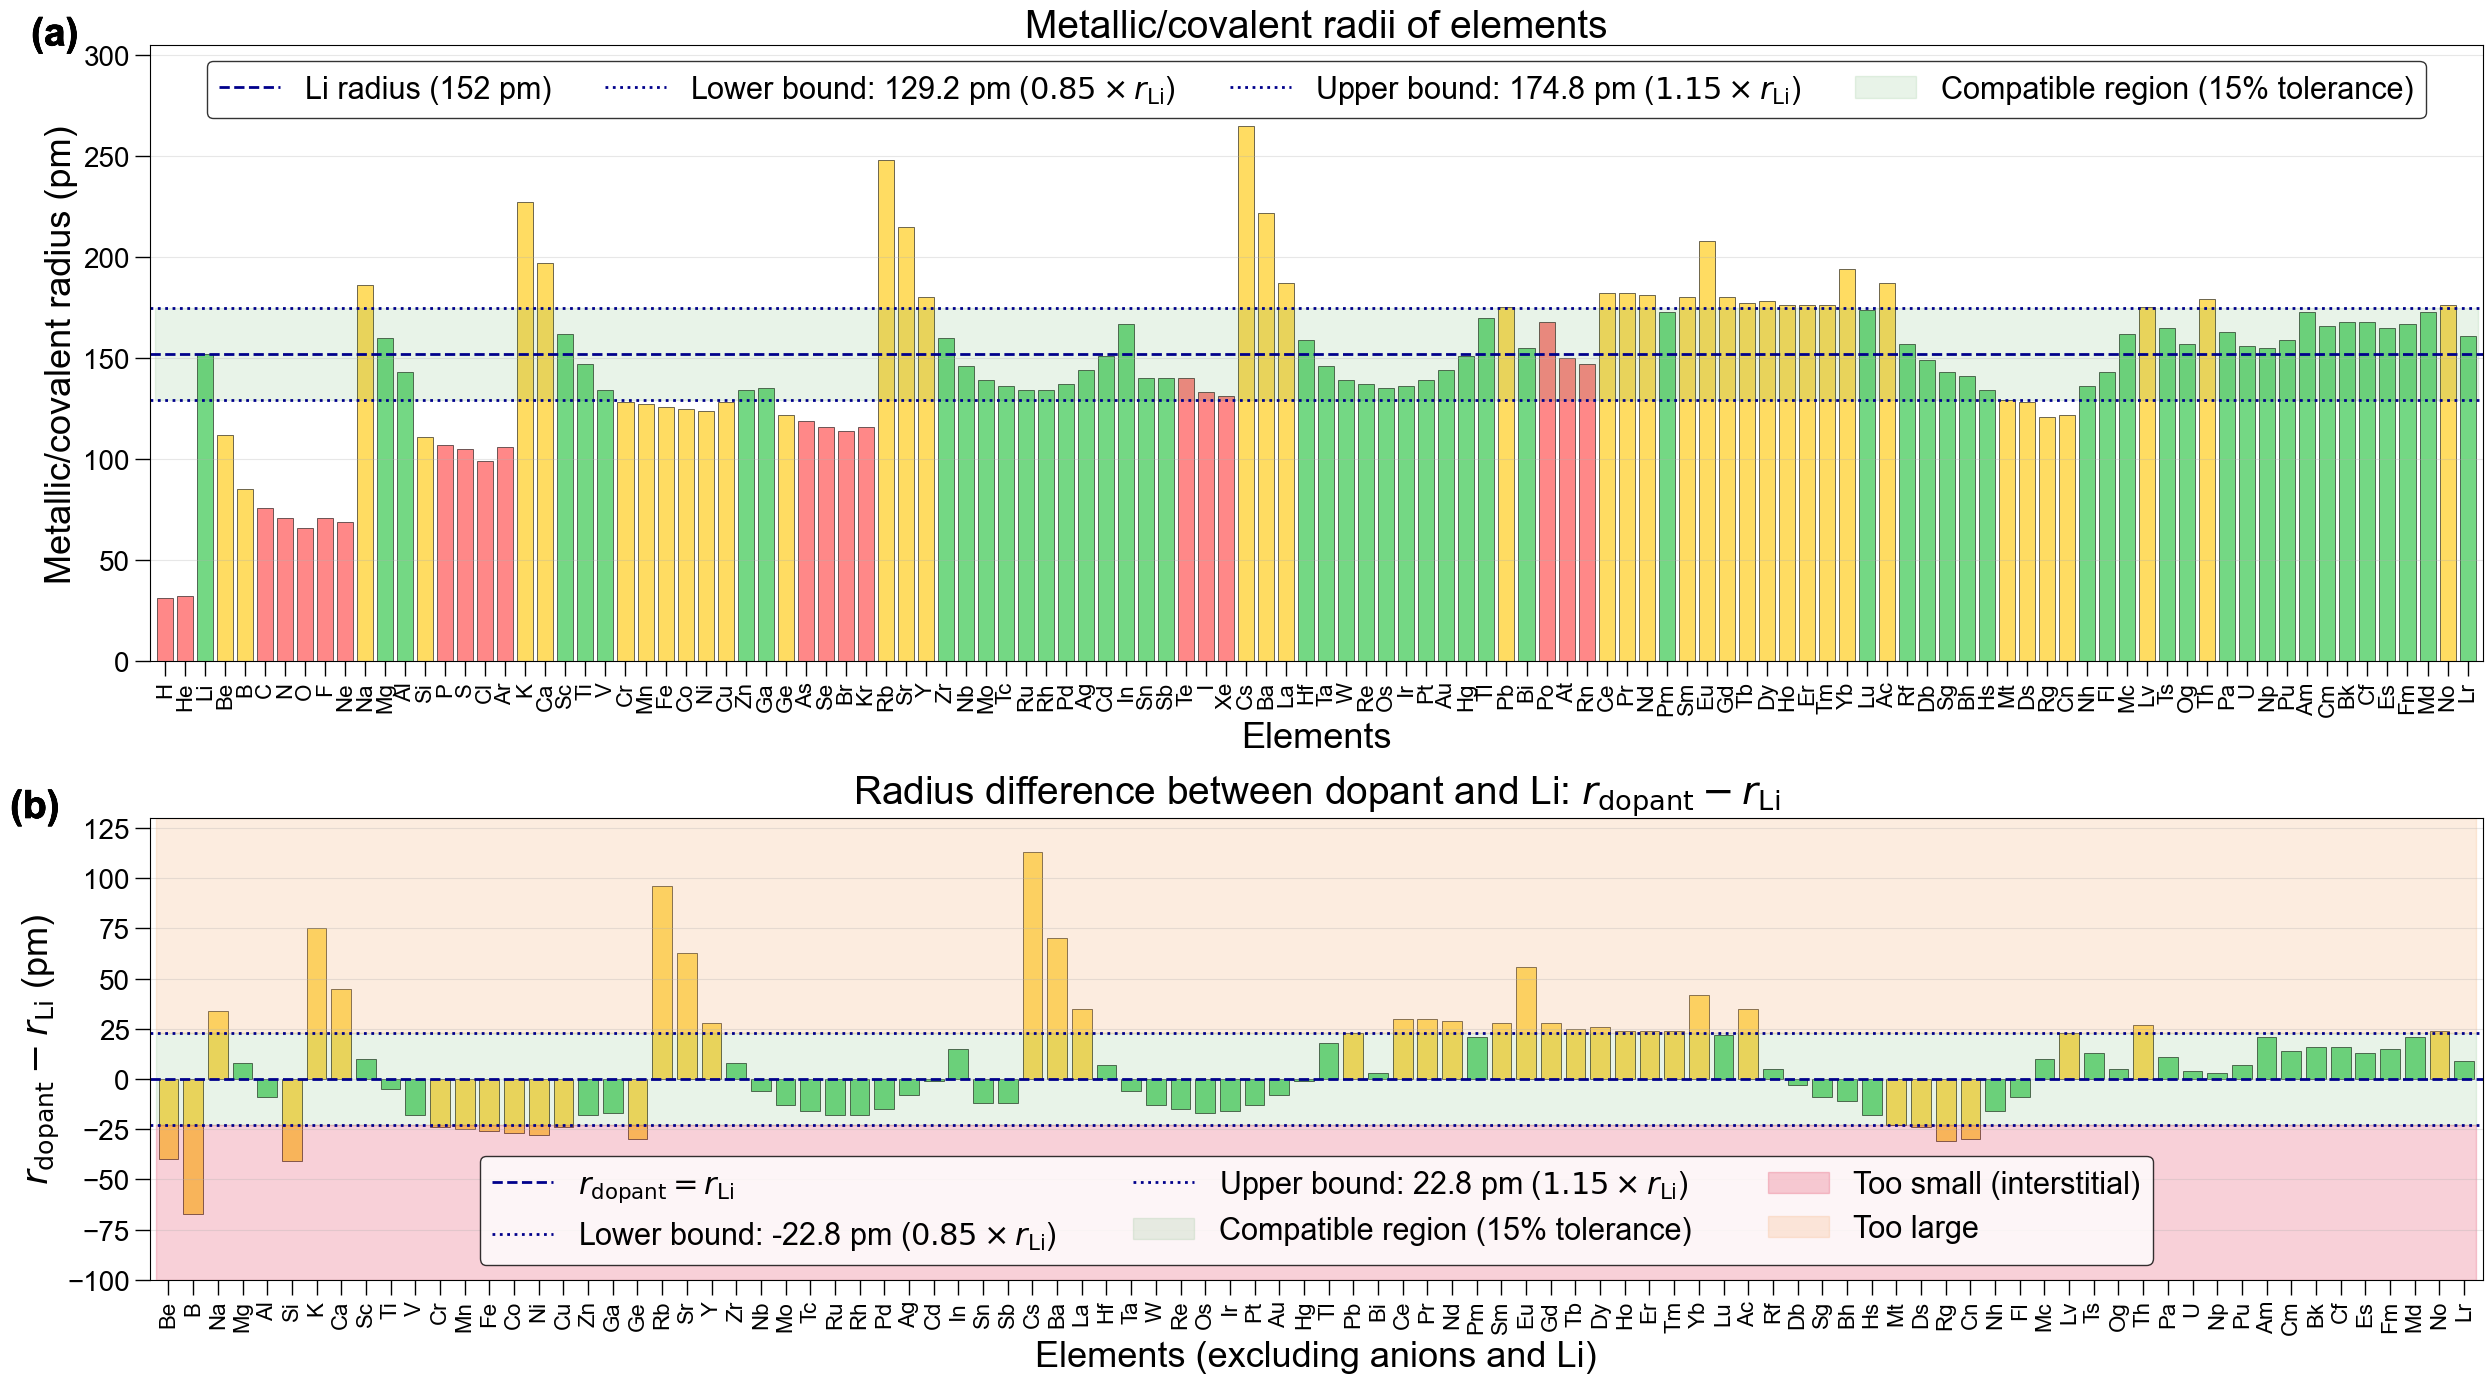


Number of elements with radius data: 116
Number of anions excluded: 21


In [6]:
from pathlib import Path
FIGURES_DIR = Path('figures/h_r_rules')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ===== MANUAL RADII DATABASE =====
# Metallic radii for metals (12-coordinate, in picometers)
# Covalent radii for non-metals and anions (in picometers)
# Sources: CRC Handbook, Pauling, Cordero et al. (2008)

MANUAL_RADII = {
    # ===== METALLIC RADII (for metals) =====
    
    # Alkali metals
    'Li': 152, 'Na': 186, 'K': 227, 'Rb': 248, 'Cs': 265,
    
    # Alkaline earth metals
    'Be': 112, 'Mg': 160, 'Ca': 197, 'Sr': 215, 'Ba': 222,
    
    # Transition metals - Period 4
    'Sc': 162, 'Ti': 147, 'V': 134, 'Cr': 128, 'Mn': 127,
    'Fe': 126, 'Co': 125, 'Ni': 124, 'Cu': 128, 'Zn': 134,
    
    # Period 5
    'Y': 180, 'Zr': 160, 'Nb': 146, 'Mo': 139, 'Tc': 136,
    'Ru': 134, 'Rh': 134, 'Pd': 137, 'Ag': 144, 'Cd': 151,
    
    # Period 6
    'Lu': 174, 'Hf': 159, 'Ta': 146, 'W': 139, 'Re': 137,
    'Os': 135, 'Ir': 136, 'Pt': 139, 'Au': 144, 'Hg': 151,
    
    # p-block metals
    'Al': 143, 'Ga': 135, 'In': 167, 'Tl': 170, 'Sn': 140,
    'Pb': 175, 'Bi': 155,
    
    # Lanthanides
    'La': 187, 'Ce': 182, 'Pr': 182, 'Nd': 181, 'Sm': 180,
    'Eu': 208, 'Gd': 180, 'Tb': 177, 'Dy': 178, 'Ho': 176,
    'Er': 176, 'Tm': 176, 'Yb': 194,
    
    # Actinides (common ones)
    'Ac': 187, 'Th': 179, 'Pa': 163, 'U': 156, 'Np': 155,
    'Pu': 159, 'Am': 173,
    
    # ===== COVALENT RADII (for non-metals and anions) =====
    'He': 32, 'Ne': 69, 'Ar': 106, 'Kr': 116, 'Xe': 131, 'Rn': 147,
    'F': 71, 'Cl': 99, 'Br': 114, 'I': 133, 'At': 150,
    'O': 66, 'S': 105, 'Se': 116, 'Te': 140, 'Po': 168,
    'N': 71, 'P': 107, 'As': 119, 'Sb': 140,
    'C': 76, 'Si': 111, 'Ge': 122,
    'B': 85,
    'H': 31,
}

# Constants
LI_METALLIC_RADIUS_PM = 152  # Fixed at 152 pm as requested
TOLERANCE = 0.15  # 15% tolerance
LOWER_BOUND = LI_METALLIC_RADIUS_PM * (1 - TOLERANCE)  # 0.85 * 152 = 129.2 pm
UPPER_BOUND = LI_METALLIC_RADIUS_PM * (1 + TOLERANCE)  # 1.15 * 152 = 174.8 pm

# Font sizes
FONTSIZE_TITLE = 28
FONTSIZE_LABEL = 26
FONTSIZE_TICK = 8
FONTSIZE_LEGEND = 22
FONTSIZE_SUPTITLE = 20

def set_fontsize(title=None, label=None, tick=None, legend=None, suptitle=None):
    """Global function to set font sizes for plots"""
    global FONTSIZE_TITLE, FONTSIZE_LABEL, FONTSIZE_TICK, FONTSIZE_LEGEND, FONTSIZE_SUPTITLE
    if title: FONTSIZE_TITLE = title
    if label: FONTSIZE_LABEL = label
    if tick: FONTSIZE_TICK = tick
    if legend: FONTSIZE_LEGEND = legend
    if suptitle: FONTSIZE_SUPTITLE = suptitle

# Helper function to classify element type
def is_metal(element_symbol):
    """Check if element is typically a metal."""
    metallic_elements = {
        'Li', 'Na', 'K', 'Rb', 'Cs', 'Fr',
        'Be', 'Mg', 'Ca', 'Sr', 'Ba', 'Ra',
        'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
        'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd',
        'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg',
        'Al', 'Ga', 'In', 'Tl', 'Sn', 'Pb', 'Bi',
        'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
        'Ac', 'Th', 'Pa', 'U', 'Np', 'Pu', 'Am'
    }
    return element_symbol in metallic_elements

def get_metallic_radius_pm(element_symbol):
    """
    Get appropriate radius for any element.
    - Uses metallic radius for metals
    - Uses covalent radius for non-metals/anions
    Returns radius in picometers.
    """
    # Special case for Li
    if element_symbol == 'Li':
        return LI_METALLIC_RADIUS_PM
    
    # Check if element exists in manual database
    if element_symbol in MANUAL_RADII:
        return MANUAL_RADII[element_symbol]
    
    # Fallback to mendeleev
    try:
        element = md.element(element_symbol)
        
        # For metals, use metallic radius
        if is_metal(element_symbol):
            if hasattr(element, 'metallic_radius_c12') and element.metallic_radius_c12:
                return element.metallic_radius_c12
            elif hasattr(element, 'metallic_radius') and element.metallic_radius:
                return element.metallic_radius
        # For non-metals, use covalent radius
        else:
            if hasattr(element, 'covalent_radius') and element.covalent_radius:
                return element.covalent_radius
    except:
        pass
    
    return None

def is_anion(element_symbol):
    """Check if element is typically an anion (non-metal)."""
    anions = {
        'O', 'F', 'Cl', 'Br', 'I', 'At',
        'H', 'N', 'P', 'As',
        'S', 'Se', 'Te', 'Po',
        'C',
        'He', 'Ne', 'Ar', 'Kr', 'Xe', 'Rn'
    }
    return element_symbol in anions

def check_li_compatibility(element_symbol):
    """
    Check if element is compatible with Li.
    Criteria: 0.85 * r_Li < r_dopant < 1.15 * r_Li
    """
    # Criterion 1: Drop if anion
    if is_anion(element_symbol):
        return False, "anion", None
    
    r_li = LI_METALLIC_RADIUS_PM
    r_element = get_metallic_radius_pm(element_symbol)
    
    if r_element is None:
        return False, f"no metallic radius data", None
    
    # Check if within 0.85-1.15 range
    if LOWER_BOUND < r_element < UPPER_BOUND:
        return True, f"compatible ({r_element:.1f} pm)", r_element
    elif r_element <= LOWER_BOUND:
        return False, f"too small (r = {r_element:.1f} pm ≤ {LOWER_BOUND:.1f} pm)", r_element
    else:
        return False, f"too large (r = {r_element:.1f} pm ≥ {UPPER_BOUND:.1f} pm)", r_element

def get_periodic_table_position(element_symbol):
    """
    Get position in periodic table for sorting.
    Returns (period, group) tuple.
    """
    try:
        element = md.element(element_symbol)
        return (element.period, element.group_id if element.group_id else 999)
    except:
        return (999, 999)

def get_element_color(element_symbol):
    """
    Determine color for each element based on criteria:
    - Red: anions
    - Yellow: does not satisfy radii criteria
    - Green: compatible
    """
    if is_anion(element_symbol):
        return '#ff6b6b'  # Red for anions
    
    compatible, _, _ = check_li_compatibility(element_symbol)
    
    if compatible:
        return '#51cf66'  # Green for compatible
    else:
        return '#ffd43b'  # Yellow for incompatible

def visualize_metallic_radii(save_path=None, figsize=(26, 14)):
    """
    Visualize metallic radii with periodic table ordering.
    Second plot shows r_dopant - r_Li difference.
    """
    # Get data for all elements
    all_elements = []
    
    # Atomic numbers 1-118
    for atomic_num in range(1, 119):
        try:
            element = md.element(atomic_num)
            
            # Get radius from manual database FIRST
            radius_pm = get_metallic_radius_pm(element.symbol)
            
            element_data = {
                'symbol': element.symbol,
                'name': element.name,
                'atomic_number': atomic_num,
                'metallic_radius_pm': radius_pm,
                'metallic_radius_ang': radius_pm / 100 if radius_pm else None,
                'is_anion': is_anion(element.symbol),
                'period': element.period,
                'group': element.group_id if element.group_id else 999
            }
            
            # Check compatibility (skip anions for radius check)
            if not is_anion(element.symbol) and radius_pm:
                compatible, _, r_val = check_li_compatibility(element.symbol)
                element_data['compatible'] = compatible
                element_data['radius_value'] = r_val
                # Calculate difference: r_dopant - r_Li
                element_data['radius_diff_pm'] = r_val - LI_METALLIC_RADIUS_PM
            else:
                element_data['compatible'] = False
                element_data['radius_value'] = None
                element_data['radius_diff_pm'] = None
            
            all_elements.append(element_data)
        except Exception as e:
            continue
    
    # Create DataFrame
    df = pd.DataFrame(all_elements)
    
    # Sort by period and group (periodic table order)
    df = df.sort_values(['period', 'group'])
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                    gridspec_kw={'height_ratios': [2, 1.5]})
    
    # ===== PLOT 1: Bar chart of metallic radii =====
    # Filter out NaN values for plotting
    df_plot1 = df[df['metallic_radius_pm'].notna()].copy()
    
    colors = [get_element_color(row['symbol']) for _, row in df_plot1.iterrows()]
    
    # Create x-axis labels with symbol only (no radius)
    x_labels = [f"{row['symbol']}" for _, row in df_plot1.iterrows()]
    
    bars = ax1.bar(range(len(df_plot1)), df_plot1['metallic_radius_pm'], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Add Li reference line
    ax1.axhline(y=LI_METALLIC_RADIUS_PM, color='darkblue', linestyle='--', 
                linewidth=2, label=f"Li radius ({LI_METALLIC_RADIUS_PM} pm)")
    
    # Add compatibility region bounds
    ax1.axhline(y=LOWER_BOUND, color='darkblue', linestyle=':', linewidth=2, 
                label=f"Lower bound: {LOWER_BOUND:.1f} pm " + r"($0.85 \times r_{\mathrm{Li}}$)")
    ax1.axhline(y=UPPER_BOUND, color='darkblue', linestyle=':', linewidth=2, 
                label=f"Upper bound: {UPPER_BOUND:.1f} pm " + r"($1.15 \times r_{\mathrm{Li}}$)")
    
    # Shade the compatible region
    x_min, x_max = -0.5, len(df_plot1) - 0.5
    ax1.fill_between([x_min, x_max], LOWER_BOUND, UPPER_BOUND,
                      alpha=0.1, color='forestgreen', 
                      label=f'Compatible region ({TOLERANCE*100:.0f}% tolerance)')
    
    ax1.set_xticks(range(len(df_plot1)))
    ax1.set_xticklabels(x_labels, rotation=90, fontsize=FONTSIZE_TICK-3)
    ax1.tick_params(axis='y', which='major', labelsize=FONTSIZE_LABEL-1)
    ax1.tick_params(axis='y', which='minor', labelsize=FONTSIZE_LABEL-3)
    ax1.tick_params(axis='x', which='major', labelsize=FONTSIZE_LABEL-8)
    ax1.tick_params(axis='x', which='minor', labelsize=FONTSIZE_LABEL-10)
    ax1.set_ylabel('Metallic/covalent radius (pm)', fontsize=FONTSIZE_LABEL)
    ax1.set_xlabel('Elements', fontsize=FONTSIZE_LABEL)
    ax1.set_title('Metallic/covalent radii of elements', fontsize=FONTSIZE_TITLE)
    ax1.legend(loc=9, fontsize=FONTSIZE_LEGEND, ncols=4, columnspacing=1.75, edgecolor="black")
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Only set ylim if there are valid radii
    if len(df_plot1) > 0 and df_plot1['metallic_radius_pm'].notna().any():
        ax1.set_ylim(0, max(df_plot1['metallic_radius_pm'].dropna()) * 1.15)
    ax1.set_xlim([-0.75, len(df_plot1)-0.25])
    
    # ===== PLOT 2: r_dopant - r_Li difference =====
    # Filter to non-anion elements with radius data
    valid_data = df[(~df['is_anion']) & 
                (df['metallic_radius_pm'].notna()) & 
                (df['symbol'] != 'Li')].copy()  # Exclude Li
    
    # Calculate difference if not already calculated
    valid_data['radius_diff_pm'] = valid_data['metallic_radius_pm'] - LI_METALLIC_RADIUS_PM
    
    if len(valid_data) > 0:
        colors_diff = ['#51cf66' if row['compatible'] else '#ffd43b' 
                       for _, row in valid_data.iterrows()]
        
        # Create bar chart of differences
        bars2 = ax2.bar(range(len(valid_data)), valid_data['radius_diff_pm'], 
                        color=colors_diff, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        ax2.set_xticks(range(len(valid_data)))
        ax2.set_xticklabels([f"{row['symbol']}" for _, row in valid_data.iterrows()], rotation=90, fontsize=FONTSIZE_TICK)
    else:
        ax2.set_xticks([])
        ax2.text(0.5, 0.5, 'No valid dopants found', transform=ax2.transAxes, 
                ha='center', va='center', fontsize=FONTSIZE_TITLE)
    
    # Add zero line (r_dopant = r_Li)
    ax2.axhline(y=0, color='darkblue', linestyle='--', linewidth=2,
                label=r'$r_{\mathrm{dopant}} = r_{\mathrm{Li}}$')
    
    # Add tolerance bounds
    lower_diff = LOWER_BOUND - LI_METALLIC_RADIUS_PM  # 129.2 - 152 = -22.8 pm
    upper_diff = UPPER_BOUND - LI_METALLIC_RADIUS_PM  # 174.8 - 152 = 22.8 pm
    
    ax2.axhline(y=lower_diff, color='darkblue', linestyle=':', linewidth=2,
                label=f'Lower bound: {lower_diff:.1f} pm ' + r"($0.85 \times r_{\mathrm{Li}}$)")
    ax2.axhline(y=upper_diff, color='darkblue', linestyle=':', linewidth=2,
                label=f'Upper bound: {upper_diff:.1f} pm ' + r"($1.15 \times r_{\mathrm{Li}}$)")
    
    # Set y-limits FIRST then get values for fills
    ax2.set_ylim([-100, 130])
    y_min, y_max = ax2.get_ylim()
    
    # Shade the compatible region
    ax2.fill_between([-0.5, max(0.5, len(valid_data)-0.5)], lower_diff, upper_diff,
                      alpha=0.1, color='forestgreen', 
                      label=f'Compatible region ({TOLERANCE*100:.0f}% tolerance)')
    
    # Color the regions outside bounds
    ax2.fill_between([-0.5, max(0.5, len(valid_data)-0.5)], y_min, lower_diff,
                      alpha=0.2, color='crimson', label='Too small (interstitial)')
    ax2.fill_between([-0.5, max(0.5, len(valid_data)-0.5)], upper_diff, y_max,
                      alpha=0.2, color='sandybrown', label='Too large')
    
    ax2.tick_params(axis='y', which='major', labelsize=FONTSIZE_LABEL-1)
    ax2.tick_params(axis='y', which='minor', labelsize=FONTSIZE_LABEL-3)
    ax2.tick_params(axis='x', which='major', labelsize=FONTSIZE_LABEL-6)
    ax2.tick_params(axis='x', which='minor', labelsize=FONTSIZE_LABEL-8)
    ax2.set_ylabel(r'$r_{\mathrm{dopant}} - r_{\mathrm{Li}}$ (pm)', fontsize=FONTSIZE_LABEL)
    ax2.set_xlabel('Elements (excluding anions and Li)', fontsize=FONTSIZE_LABEL)
    ax2.set_title(r'Radius difference between dopant and Li: $r_{\mathrm{dopant}} - r_{\mathrm{Li}}$', 
                  fontsize=FONTSIZE_TITLE)
    
    ax2.set_xlim([-0.75, max(0.75, len(valid_data)-0.25)])
    ax2.legend(loc=8, fontsize=FONTSIZE_LEGEND, ncols=3, columnspacing=2.5, edgecolor="black")
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add panel labels
    ax1.text(-0.051, 1.0, '(a)', transform=ax1.transAxes, fontsize=FONTSIZE_TITLE, fontweight='bold',
          path_effects=[mpe.withStroke(linewidth=0, foreground='white'),
                      mpe.withStroke(linewidth=0.5, foreground='black')])
    ax2.text(-0.060, 1.0, '(b)', transform=ax2.transAxes, fontsize=FONTSIZE_TITLE, fontweight='bold',
          path_effects=[mpe.withStroke(linewidth=0, foreground='white'),
                      mpe.withStroke(linewidth=0.5, foreground='black')])

    ax1.tick_params(axis='y', which='major', length=11, width=1.0, labelsize=FONTSIZE_TICK+12, colors='black')
    ax1.tick_params(axis='y', which='minor', length=6, width=0.7, labelsize=FONTSIZE_TICK+10)
    ax1.tick_params(axis='x', which='major', length=11, width=1.0, labelsize=FONTSIZE_TICK+8, colors='black')
    ax1.tick_params(axis='x', which='minor', length=6, width=0.7, labelsize=FONTSIZE_TICK+6)
    ax1.locator_params(axis='y', nbins=10)  

    ax2.tick_params(axis='y', which='major', length=11, width=1.0, labelsize=FONTSIZE_TICK+12, colors='black')
    ax2.tick_params(axis='y', which='minor', length=6, width=0.7, labelsize=FONTSIZE_TICK+10)
    ax2.tick_params(axis='x', which='major', length=11, width=1.0, labelsize=FONTSIZE_TICK+8, colors='black')
    ax2.tick_params(axis='x', which='minor', length=6, width=0.7, labelsize=FONTSIZE_TICK+6)
    ax2.locator_params(axis='y', nbins=10)  

    fig.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return df

def create_element_summary_table():
    """
    Create a summary table for all elements.
    """
    summary = []
    
    for atomic_num in range(1, 119):
        try:
            element = md.element(atomic_num)
            r_pm = get_metallic_radius_pm(element.symbol)
            
            if r_pm is None and not is_anion(element.symbol):
                status = "No data"
                color = "gray"
            elif is_anion(element.symbol):
                status = "Anion (excluded)"
                color = 'crimson'
            else:
                compatible, reason, r_val = check_li_compatibility(element.symbol)
                if compatible:
                    diff = r_val - LI_METALLIC_RADIUS_PM
                    status = f"✓ Compatible (Δ = {diff:+.1f} pm)"
                    color = 'forestgreen'
                else:
                    status = f"✗ {reason}"
                    color = "yellow"
            
            summary.append({
                'Atomic #': atomic_num,
                'Symbol': element.symbol,
                'Name': element.name,
                'Metallic Radius (pm)': r_pm if r_pm else 'N/A',
                'r_dopant - r_Li (pm)': (r_pm - LI_METALLIC_RADIUS_PM) if r_pm and not is_anion(element.symbol) else 'N/A',
                'Status': status,
                'Color': color
            })
        except:
            continue
    
    df_summary = pd.DataFrame(summary)
    return df_summary

def analyze_structure(structure_path):
    """
    Analyze a structure file and color atoms by criteria.
    """
    atoms = read(structure_path)
    
    print(f"\nAnalyzing structure: {structure_path}")
    print(f"Li metallic radius: {LI_METALLIC_RADIUS_PM} pm")
    print(r"Compatibility criterion: $0.85 \times r_{\mathrm{Li}} < r_{\mathrm{dopant}} < 1.15 \times r_{\mathrm{Li}}$")
    print(f"  Lower bound: {LOWER_BOUND:.1f} pm")
    print(f"  Upper bound: {UPPER_BOUND:.1f} pm")
    print("="*60)
    
    results = []
    for atom in atoms:
        element = atom.symbol
        r = get_metallic_radius_pm(element)
        is_anion_flag = is_anion(element)
        
        if is_anion_flag:
            status = "ANION"
            color = 'crimson'
            compatible = False
            diff = None
        elif r is None:
            status = "NO RADIUS DATA"
            color = 'sandybrown'
            compatible = False
            diff = None
        else:
            diff = r - LI_METALLIC_RADIUS_PM
            if LOWER_BOUND < r < UPPER_BOUND:
                status = f"COMPATIBLE (Δ = {diff:+.1f} pm)"
                color = 'forestgreen'
                compatible = True
            elif r <= LOWER_BOUND:
                status = f"TOO SMALL (Δ = {diff:+.1f} pm, interstitial)"
                color = "sandybrown"
                compatible = False
            else:
                status = f"TOO LARGE (Δ = {diff:+.1f} pm)"
                color = "sandybrown"
                compatible = False
        
        results.append({
            'element': element,
            'radius_pm': r,
            'radius_diff_pm': diff,
            'status': status,
            'color': color,
            'compatible': compatible
        })
        
        # Print each atom
        diff_str = f"{diff:+3.0f}" if diff is not None else " N/A"
        print(f"{atom.symbol:3s} | r = {r:3.0f} pm | Δ = {diff_str} pm | {status}")
    
    # Summary statistics
    total = len(results)
    compatible = sum(1 for r in results if r['compatible'])
    incompatible = sum(1 for r in results if not r['compatible'] and not is_anion(r['element']) and r['radius_pm'] is not None)
    anions = sum(1 for r in results if is_anion(r['element']))
    no_data = sum(1 for r in results if r['radius_pm'] is None and not is_anion(r['element']))
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Total atoms: {total}")
    print(f"✓ Compatible: {compatible} (green)")
    print(f"✗ Incompatible (size mismatch): {incompatible} (yellow)")
    print(f"✗ Anions: {anions} (red)")
    if no_data > 0:
        print(f"? No radius data: {no_data} (orange)")
    
    return results

# ===== MAIN EXECUTION =====

if __name__ == "__main__":
    # 1. Visualize all elements with periodic table ordering
    print("="*70)
    print("VISUALIZING METALLIC RADII (Periodic Table Order)")
    print("="*70)
    print(f"Li metallic radius: {LI_METALLIC_RADIUS_PM} pm")
    print(f"Compatibility criterion: 0.85×r_Li < r_dopant < 1.15×r_Li")
    print(f"  = {LOWER_BOUND:.1f} pm < r_dopant < {UPPER_BOUND:.1f} pm")
    print(f"  = {LOWER_BOUND - LI_METALLIC_RADIUS_PM:.1f} pm < (r_dopant - r_Li) < {UPPER_BOUND - LI_METALLIC_RADIUS_PM:.1f} pm")
    
    # Create visualization
    df_radii = visualize_metallic_radii(save_path=str(FIGURES_DIR / "metallic_radii_analysis.pdf"))
    
    # Print number of elements found
    print(f"\nNumber of elements with radius data: {df_radii['metallic_radius_pm'].notna().sum()}")
    print(f"Number of anions excluded: {df_radii['is_anion'].sum()}")
    
    if 0:
        # 2. Create summary table
        print("\n" + "="*70)
        print("ELEMENT SUMMARY TABLE")
        print("="*70)
        df_summary = create_element_summary_table()
        
        # Save to CSV
        df_summary.to_csv(FIGURES_DIR / "li_compatibility_summary.csv", index=False)
        summary_path = FIGURES_DIR / 'li_compatibility_summary.csv'
        print(f'Summary saved to: {summary_path}')
        
        # Show compatible elements
        print("\n" + "="*70)
        print("COMPATIBLE ELEMENTS (Green)")
        print("="*70)
        compatible_list = df_summary[
            (df_summary['Status'].str.contains('Compatible', na=False))
        ]['Symbol'].tolist()
        print(f"Elements with {LOWER_BOUND:.1f} pm < r < {UPPER_BOUND:.1f} pm:")
        print(f"  {compatible_list}")
        
        print("\n" + "="*70)
        print("INCOMPATIBLE ELEMENTS - TOO SMALL (Yellow)")
        print("="*70)
        too_small_list = df_summary[
            (df_summary['Status'].str.contains('too small', na=False))
        ]['Symbol'].tolist()
        print(f"Elements with r ≤ {LOWER_BOUND:.1f} pm (would be interstitial):")
        print(f"  {too_small_list}")
        
        print("\n" + "="*70)
        print("INCOMPATIBLE ELEMENTS - TOO LARGE (Yellow)")
        print("="*70)
        too_large_list = df_summary[
            (df_summary['Status'].str.contains('too large', na=False))
        ]['Symbol'].tolist()
        print(f"Elements with r ≥ {UPPER_BOUND:.1f} pm:")
        print(f"  {too_large_list}")
        
        print("\n" + "="*70)
        print("ANIONS (Red - Excluded)")
        print("="*70)
        anion_list = df_summary[
            (df_summary['Status'] == 'Anion (excluded)')
        ]['Symbol'].tolist()
        print(f"  {anion_list}")
    
        


In [7]:
anion_list = ['O', 'F', 'Cl', 'Br', 'I', 'H', 'N', 'S', 'C', 'P']

In [8]:
import mendeleev as md

In [9]:

# Test a few elements
test_elements = ['Li', 'Na', 'K', 'Mg', 'Al', 'Ni', 'Cu', "Bi", "Au"]

print("Element | Metallic radius from mendeleev (pm)")
print("-" * 45)
for symbol in test_elements:
    element = md.element(symbol)
    if hasattr(element, 'metallic_radius') and element.metallic_radius_c12:
        print(f"{symbol:7} | {element.metallic_radius_c12:.1f} pm")
    else:
        print(f"{symbol:7} | No data")

        

Element | Metallic radius from mendeleev (pm)
---------------------------------------------
Li      | 155.0 pm
Na      | 190.0 pm
K       | 235.0 pm
Mg      | 160.0 pm
Al      | 143.0 pm
Ni      | 124.0 pm
Cu      | 128.0 pm
Bi      | 178.0 pm
Au      | 144.0 pm


In [10]:
element = md.element("Li")


In [11]:
element.metallic_radius_c12

155.0

In [12]:
dir(element)

['__abstract__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__mapper__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__table__',
 '__tablename__',
 '__weakref__',
 '_ionization_energies',
 '_oxidation_states',
 '_sa_class_manager',
 '_sa_instance_state',
 '_sa_registry',
 '_series',
 '_series_id',
 'abundance_crust',
 'abundance_sea',
 'atomic_number',
 'atomic_radius',
 'atomic_radius_rahm',
 'atomic_volume',
 'atomic_weight',
 'atomic_weight_uncertainty',
 'block',
 'boiling_point',
 'c6',
 'c6_gb',
 'cas',
 'covalent_radius',
 'covalent_radius_bragg',
 'covalent_radius_cordero',
 'covalent_radius_pyykko',
 'covalent_radius_pyykko_double',
 'covalent_radius_pyykko_triple',
 'cpk_color',
 'density',
 '

## Remaining dopants

In [13]:
dopant_list = [ 'Al', 'Bi', 'Cd', 'Ga', 'Ge', 'In', 'Pb', 'Sb', 'Si', 'Se', 'Sn', 'Tl', 'Be', 'Mg', 'Ca',
'Na', 'K', 'Ag', 'Au', 'Cu', 'Zn', 'Cr', 'Fe', 'Co', 'Ni', 'Pd', 'Pt', 'Ti', 'Zr',
'Hf', 'V', 'Nb', 'Ta', 'Mo', 'W', 'Mn', 'Ru', 'Rh', 'Os', 'Ir', 'Y', 'La', 'Sc',
'Ce', 'Nd', 'Sm', 'Re', 'Hg',
]



In [14]:
len(dopant_list)

48

In [15]:
pot_pack_thesis = {1: "H", 2: "He", 3:"Li_sv", 4: "Be_sv", 5: "B", 6: "C", 7: "N",  8:"O", 9:"F", 10: "Ne",  11:'Na_pv',
    12: "Mg_pv", 13: "Al", 14: "Si", 15: "P", 16: "S", 17: "Cl", 18: "Ar", 19: "K_sv", 20: "Ca_sv", 21: "Sc_sv", 22: "Ti_pv", 23:"V_pv",
    24: "Cr_pv", 25: "Mn_pv", 26: "Fe_pv", 27: "Co", 28: "Ni_pv", 29: "Cu_pv", 30: "Zn", 31: "Ga_d", 32: "Ge_d", 33: 'As', 34: "Se",
    35: "Br", 36: "Kr", 37: "Rb_sv", 38: "Sr_sv", 39: "Y_sv", 40: "Zr_sv", 41: "Nb_pv", 42: "Mo_pv", 43: "Tc_pv", 44: "Ru_pv", 45: "Rh_pv", 46: "Pd", 47: "Ag", 48: "Cd", 49: "In_d", 50: "Sn_d", 51: "Sb", 52: "Te", 53: "I", 54: "Xe", 55: "Cs_sv", 56: "Ba_sv", 57: "La",
    58: "Ce", 59: "Pr_3", 60: "Nd_3", 61: "Pm_3", 62: "Sm_3", 63: "Eu", 64: "Gd", 65: "Tb_3", 66: "Dy_3", 67: "Ho_3", 68: "Er_3",
    69: "Tm_3", 70: "Yb_3", 71: "Lu_3", 72: "Hf_pv", 73: "Ta_pv", 74: "W_pv", 75: "Re_pv", 76: "Os_pv", 77: "Ir",  78: "Pt", 79: "Au",
    80: "Hg", 81: "Tl", 82: "Pb_d", 83: "Bi", 84: "Po", 85: "At_d", 86: "Rn", }


In [16]:
sorted_list = []
not_included = []

for val in pot_pack_thesis.values():
    val = val.split("_")[0]
    if val in dopant_list:
        sorted_list.append(val)
    else:
        not_included.append(val)
    


In [17]:
len(sorted_list)

48

In [18]:
len(dopant_list)

48

In [19]:
for dop in dopant_list:
    if dop not in sorted_list:
        print(dop)

In [20]:
# POTCAR ENMAX scan (disabled; machine-local paths removed)
pass


## Methods to check Hume-Rothery rules for arbitrary elements

In [21]:
from dataclasses import dataclass
import re


In [22]:
@dataclass
class ElementData:
    Z: int               # atomic number
    r_atomic: float      # pm
    crystal: str         # polytype
    valency: int         # unit 
    chi: float           # Pauling scale


# Complete self-contained data for all elements (atomic number, metallic radius from XRD, crystal structure, valency, Pauling electronegativity χ)
ELEMENTS_DATA = {
    "H":  ElementData(1,  25,  "molecular",  1,  2.20),
    "Li": ElementData(3,  152, "bcc",        1,  0.98),
    "Be": ElementData(4,  112, "hcp",        2,  1.57),
    "B":  ElementData(5,   85, "beta_rhombohedral", 3,  2.04), 
    "Na": ElementData(11, 186, "bcc",        1,  0.93),
    "Mg": ElementData(12, 160, "hcp",        2,  1.31),
    "Al": ElementData(13, 143, "fcc",        3,  1.61),
    "Si": ElementData(14, 111, "diamond",    4,  1.90),
    "K":  ElementData(19, 227, "bcc",        1,  0.82),
    "Ca": ElementData(20, 197, "fcc",        2,  1.00),
    "Sc": ElementData(21, 162, "hcp",        3,  1.36),
    "Ti": ElementData(22, 147, "hcp",        4,  1.54),
    "V":  ElementData(23, 134, "bcc",        5,  1.63),
    "Cr": ElementData(24, 128, "bcc",        3,  1.66),  # Cr  +3, +6
    "Mn": ElementData(25, 127, "complex",    2,  1.55),  # Mn  +2
    "Fe": ElementData(26, 126, "bcc",        2,  1.83),  # Fe  +2, +3
    "Co": ElementData(27, 125, "hcp",        2,  1.88),  # Co  +2
    "Ni": ElementData(28, 124, "fcc",        2,  1.91),  # Ni  +2
    "Cu": ElementData(29, 128, "fcc",        1,  1.90),  # Cu +1
    "Zn": ElementData(30, 134, "hcp",        2,  1.65),  # Zn +2
    "Ga": ElementData(31, 135, "ortho",      3,  1.81),
    "Ge": ElementData(32, 122, "diamond",    4,  2.01),
    "As": ElementData(33, 119, "rhombo",     5,  2.18),
    "Rb": ElementData(37, 248, "bcc",        1,  0.82),
    "Sr": ElementData(38, 215, "fcc",        2,  0.95),
    "Y":  ElementData(39, 180, "hcp",        3,  1.22),
    "Zr": ElementData(40, 160, "hcp",        4,  1.33),
    "Nb": ElementData(41, 146, "bcc",        5,  1.60),
    "Mo": ElementData(42, 139, "bcc",        6,  2.16),  # Mo  +6
    "Tc": ElementData(43, 136, "hcp",        7,  1.90),
    "Ru": ElementData(44, 134, "hcp",        3,  2.20),  # Ru  +3
    "Rh": ElementData(45, 134, "fcc",        3,  2.28),  # Rh  +3
    "Pd": ElementData(46, 137, "fcc",        2,  2.20),  # Pd  +2
    "Ag": ElementData(47, 144, "fcc",        1,  1.93),  # Ag +1
    "Cd": ElementData(48, 151, "hcp",        2,  1.69),  # Cd +2
    "In": ElementData(49, 167, "tetra",      3,  1.78),
    "Sn": ElementData(50, 140, "tetra",      4,  1.96),
    "Sb": ElementData(51, 140, "rhombo",     5,  2.05),
    "Cs": ElementData(55, 265, "bcc",        1,  0.79),
    "Ba": ElementData(56, 222, "bcc",        2,  0.89),
    "Hf": ElementData(72, 159, "hcp",        4,  1.30),
    "Ta": ElementData(73, 146, "bcc",        5,  1.50),
    "W":  ElementData(74, 139, "bcc",        6,  2.36),  # W  +6
    "Re": ElementData(75, 137, "hcp",        7,  1.90),
    "Os": ElementData(76, 135, "hcp",        4,  2.20),  # Os  +4
    "Ir": ElementData(77, 136, "fcc",        3,  2.20),  # Ir  +3
    "Pt": ElementData(78, 139, "fcc",        2,  2.28),  # Pt  +2
    "Au": ElementData(79, 144, "fcc",        1,  2.54),  # Au +1
    "Hg": ElementData(80, 151, "rhombo",     2,  2.00),  # Hg +2
    "Bi": ElementData(83, 155, "rhombo",     5,  2.02),
    "La": ElementData(57, 187, "dhcp",       3,  1.10),
    "Ce": ElementData(58, 182, "fcc",        3,  1.12),
    "Pr": ElementData(59, 182, "hcp",        3,  1.13),
    "Nd": ElementData(60, 181, "hcp",        3,  1.14),
    "Sm": ElementData(62, 180, "rhombo",     3,  1.17),
    "Eu": ElementData(63, 208, "bcc",        2,  0.63),  # Eu  +2
    "Gd": ElementData(64, 180, "hcp",        3,  1.20),
    "Tb": ElementData(65, 177, "hcp",        3,  1.22),
    "Dy": ElementData(66, 178, "hcp",        3,  1.22),
    "Ho": ElementData(67, 176, "hcp",        3,  1.23),
    "Er": ElementData(68, 176, "hcp",        3,  1.24),
    "Tm": ElementData(69, 176, "hcp",        3,  1.25),
    "Yb": ElementData(70, 194, "fcc",        2,  1.10),  # Yb  +2
    "Lu": ElementData(71, 174, "hcp",        3,  1.27),
}

def get_element_data(sym: str) -> ElementData:
    sym = sym.strip().title()   # works for all "li" -> "Li", "LI" -> "Li"
    data = ELEMENTS_DATA.get(sym)
    if data is None:
        raise ValueError(f"Element '{sym}' not found. Available: {list(ELEMENTS_DATA.keys())[:10]}...")
    return data

def hume_rothery_report(A_sym: str, B_sym: str,
                        size_tol: float = 0.15,
                        chi_tol: float = 0.4) -> None:
    try:
        A = get_element_data(A_sym)
        B = get_element_data(B_sym)
    except ValueError as err:
        print(f"Error: {err}")
        return

    print(f"=== Hume–Rothery check: {A_sym} in {B_sym} (and vice versa) ===\n")

    # 1. Atomic size
    mismatch = (A.r_atomic - B.r_atomic) / max(A.r_atomic, B.r_atomic)
    difference = A.r_atomic - B.r_atomic
    ok_size = mismatch <= size_tol
    print("1) Atomic size rule:")
    print(f"   radii: r({A_sym}) = {A.r_atomic} pm, r({B_sym}) = {B.r_atomic} pm")
    print(f"   mismatch = {mismatch*100:.1f}% (tol {size_tol*100:.0f}%)")
    print("   ->", "✓ SATISFIED" if ok_size else "✗ NOT satisfied", "\n")

    # 2. Crystal structure
    same_struct = (A.crystal == B.crystal and A.crystal != "unknown")
    # if (A.crystal == 'hcp' and B.crystal == 'bcc') or (A.crystal == 'fcc' and B.crystal == 'hcp'):
    if (A.crystal == 'fcc' and B.crystal == 'bcc'):
        same_struct = True
    print("2) Crystal structure rule:")
    print(f"   structures: {A_sym} = {A.crystal}, {B_sym} = {B.crystal}")
    print("   ->", "✓ SATISFIED" if same_struct else "✗ NOT/mismatch", "\n")

    # 3. valency
    same_valency = (A.valency == B.valency and A.valency != "unknown")
    valency_dif = abs(A.valency - B.valency)
    val_higher = (A.valency < B.valency)
    print("3) valency rule:")
    print(f"   valency: {A_sym} = {A.valency}, {B_sym} = {B.valency}")
    if A.valency == B.valency:
        print("   -> ✓ SAME valency\n")
    else:
        print(f"   -> ⚠ PARTIALLY ({A_sym} valency {'higher' if A.valency > B.valency else 'lower'})\n")

    # 4. Electronegativity
    d_chi = abs(A.chi - B.chi)
    d_chi_per = abs(A.chi - B.chi)/max(A.chi, B.chi)
    ok_chi = d_chi <= chi_tol
    print("4) Electronegativity rule:")
    print(f"   χ({A_sym}) = {A.chi:.2f}, χ({B_sym}) = {B.chi:.2f}, |Δχ| = {d_chi:.2f}")
    print("   ->", "✓ SATISFIED" if ok_chi else "✗ NOT satisfied")
    return ok_size, difference, mismatch, same_struct, same_valency, valency_dif, val_higher, d_chi, d_chi_per, ok_chi
    


In [23]:
from hume_rothery_data import ELEMENTS_DATA, save_hume_rothery_csv

# Write data/hume_rothery_data.csv from ELEMENTS_DATA
path = save_hume_rothery_csv()
print(f"Wrote {path}")


Wrote /home/arseniy/Desktop/work/solid_solutions_li/data/hume_rothery_data.csv


In [24]:
import pandas as pd

data = pd.read_csv(path)
data.head()


,element,Z,r_atomic_pm,crystal,valency,chi
0,H,1,25,molecular,1,2.20
1,Li,3,152,bcc,1,0.98
2,Be,4,112,hcp,2,1.57
3,B,5,85,beta_rhombohedral,3,2.04
4,Na,11,186,bcc,1,0.93


In [25]:
import io
import sys
from contextlib import redirect_stdout

#appending rule 1
f = io.StringIO()
with redirect_stdout(f):
    result = [hume_rothery_report('Li', sym.strip().title()) for sym in ELEMENTS_DATA]
    new_column_values_log = [item[0] for item in result]
    new_column_values_dif_a = [item[1] for item in result]
    new_column_values_dif_per = [item[2]*100 for item in result]

data['Rule 1, logic'] = new_column_values_log
data['Rule 1, difference, pm'] = new_column_values_dif_a
data['Rule 1, difference, %'] = new_column_values_dif_per

#appending rule 2
f = io.StringIO()
with redirect_stdout(f):
    result = [hume_rothery_report('Li', sym.strip().title()) for sym in ELEMENTS_DATA]
    same_struct = [item[3] for item in result]

data['Rule 2, logic'] = same_struct

#appending rule 3
f = io.StringIO()
with redirect_stdout(f):
    result = [hume_rothery_report('Li', sym.strip().title()) for sym in ELEMENTS_DATA]
    same_valency = [item[4] for item in result]
    valency_dif = [item[5] for item in result]
    val_higher = [item[6] for item in result]
    
data['Rule 3, logic'] = same_valency
data['Rule 3, valency difference, unit'] = valency_dif
data['Rule 3, valency of dopant is higher, logic'] = val_higher

#appending rule 4
f = io.StringIO()
with redirect_stdout(f):
    result = [hume_rothery_report('Li', sym.strip().title()) for sym in ELEMENTS_DATA]
    d_chi = [item[7] for item in result]
    d_chi_per = [item[8] * 100 for item in result]
    ok_chi = [item[9] for item in result]

data['Rule 4, logic'] = ok_chi
data['Rule 4, difference, Pauling scale'] = d_chi
data['Rule 4, %'] = d_chi_per


FIGURES_DIR = Path("figures/h_r_rules"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
data.to_csv(FIGURES_DIR / "elements_data.csv", index=False)
data



,element,Z,r_atomic_pm,crystal,valency,chi,"Rule 1, logic","Rule 1, difference, pm","Rule 1, difference, %","Rule 2, logic","Rule 3, logic","Rule 3, valency difference, unit","Rule 3, valency of dopant is higher, logic","Rule 4, logic","Rule 4, difference, Pauling scale","Rule 4, %"
0,H,1,25,molecular,1,2.20,False,127,83.552632,False,True,0,False,False,1.22,55.454545
1,Li,3,152,bcc,1,0.98,True,0,0.000000,True,True,0,False,True,0.00,0.000000
2,Be,4,112,hcp,2,1.57,False,40,26.315789,False,False,1,True,False,0.59,37.579618
3,B,5,85,beta_rhombohedral,3,2.04,False,67,44.078947,False,False,2,True,False,1.06,51.960784
4,Na,11,186,bcc,1,0.93,True,-34,-18.279570,True,True,0,False,True,0.05,5.102041
5,Mg,12,160,hcp,2,1.31,True,-8,-5.000000,False,False,1,True,True,0.33,25.190840
6,Al,13,143,fcc,3,1.61,True,9,5.921053,False,False,2,True,False,0.63,39.130435
7,Si,14,111,diamond,4,1.90,False,41,26.973684,False,False,3,True,False,0.92,48.421053
8,K,19,227,bcc,1,0.82,True,-75,-33.039648,True,True,0,False,True,0.16,16.326531
9,Ca,20,197,fcc,2,1.00,True,-45,-22.842640,False,False,1,True,True,0.02,2.000000


In [26]:
hume_rothery_report("Li", "Mg")
print("\n" + "="*60 + "\n")


=== Hume–Rothery check: Li in Mg (and vice versa) ===

1) Atomic size rule:
   radii: r(Li) = 152 pm, r(Mg) = 160 pm
   mismatch = -5.0% (tol 15%)
   -> ✓ SATISFIED 

2) Crystal structure rule:
   structures: Li = bcc, Mg = hcp
   -> ✗ NOT/mismatch 

3) valency rule:
   valency: Li = 1, Mg = 2
   -> ⚠ PARTIALLY (Li valency lower)

4) Electronegativity rule:
   χ(Li) = 0.98, χ(Mg) = 1.31, |Δχ| = 0.33
   -> ✓ SATISFIED




## Criteria validation

In [27]:
from pathlib import Path
FIGURES_DIR = Path('figures/h_r_rules')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(FIGURES_DIR / "elements_data.csv")


In [28]:
data.head()

,element,Z,r_atomic_pm,crystal,valency,chi,"Rule 1, logic","Rule 1, difference, pm","Rule 1, difference, %","Rule 2, logic","Rule 3, logic","Rule 3, valency difference, unit","Rule 3, valency of dopant is higher, logic","Rule 4, logic","Rule 4, difference, Pauling scale","Rule 4, %"
0,H,1,25,molecular,1,2.20,False,127,83.552632,False,True,0,False,False,1.22,55.454545
1,Li,3,152,bcc,1,0.98,True,0,0.000000,True,True,0,False,True,0.00,0.000000
2,Be,4,112,hcp,2,1.57,False,40,26.315789,False,False,1,True,False,0.59,37.579618
3,B,5,85,beta_rhombohedral,3,2.04,False,67,44.078947,False,False,2,True,False,1.06,51.960784
4,Na,11,186,bcc,1,0.93,True,-34,-18.279570,True,True,0,False,True,0.05,5.102041


In [29]:
radius_diffs = data["Rule 1, difference, %"]

In [30]:
solid_solutions_cand = {
    "Na": "narrow", 
    "B": "narrow",  # new
    "La": "narrow",  # new
    "Y": "small",   # new 
    "Mg": "wide",
    "Ca": "small", 
    "Cu": "narrow",
    "Zn": "narrow",
    "Ga": "narrow",
    "Ge": "narrow",
    "Rh": "narrow",
    "Pd": "narrow",
    "Ag": "small",
    "Cd": "wide",
    "In": "narrow",
    # "Sn": "narrow",
    "Ir": "narrow",
    "Pt": "narrow",
    "Au": "small",
    "Hg": "narrow",
    "Tl": "narrow",
    "Pb": "narrow",
    "Bi": "narrow",
    "Si": "narrow",
    
    
}



## Rule 1

In [31]:
ss_dopants = list(solid_solutions_cand.keys())


In [32]:
# --- select only dopants that form solid solution with Li ---
ss_dopants = list(solid_solutions_cand.keys())

mask_ss = data["element"].isin(ss_dopants)
df_ss = data.loc[mask_ss].copy().reset_index(drop=True)

df_ss["|Rule 1, difference, %|"] = np.abs(df_ss["Rule 1, difference, %"])
df_ss_sorted = df_ss.sort_values("|Rule 1, difference, %|")

sorted_diffs = df_ss_sorted["|Rule 1, difference, %|"].values
sorted_elements = df_ss_sorted["element"].values
n = len(df_ss)

print("Radius differences and elements:")
for diff, el in zip(sorted_diffs, sorted_elements):
    print(f"{el:4s}: {diff:6.3f} %")


Radius differences and elements:
Cd  :  0.658 %
La  :  4.403 %
Mg  :  5.000 %
Ag  :  5.263 %
In  :  8.982 %
Pd  :  9.868 %
Ga  : 11.184 %
Zn  : 11.842 %
Rh  : 11.842 %
Bi  : 12.644 %
Ir  : 13.636 %
Au  : 13.636 %
Pt  : 13.636 %
Y   : 15.556 %
Cu  : 15.789 %
Na  : 18.280 %
Ge  : 19.737 %
Hg  : 21.649 %
Ca  : 22.843 %
Si  : 26.974 %
B   : 44.079 %


In [33]:
# Define the interpolation function BEFORE using it
def find_x_at_percentile(target_percent, sorted_diffs, cum_percent):
    """
    Find |Δr| value at target cumulative percentile.
    
    Parameters:
    - target_percent: desired percentile (e.g., 68, 95, 99.7)
    - sorted_diffs: sorted |Δr| values
    - cum_percent: cumulative percentages corresponding to sorted_diffs
    
    Returns:
    - x_value: |Δr| at the target percentile
    """
    if target_percent <= cum_percent[0]:
        return sorted_diffs[0]
    if target_percent >= cum_percent[-1]:
        return sorted_diffs[-1]
    
    # Find interpolation indices
    idx = np.searchsorted(cum_percent, target_percent)
    if idx == 0:
        return sorted_diffs[0]
    
    # Linear interpolation
    x1, x2 = sorted_diffs[idx-1], sorted_diffs[idx]
    y1, y2 = cum_percent[idx-1], cum_percent[idx]
    
    if y2 == y1:
        return x1
    
    t = (target_percent - y1) / (y2 - y1)
    return x1 + t * (x2 - x1)

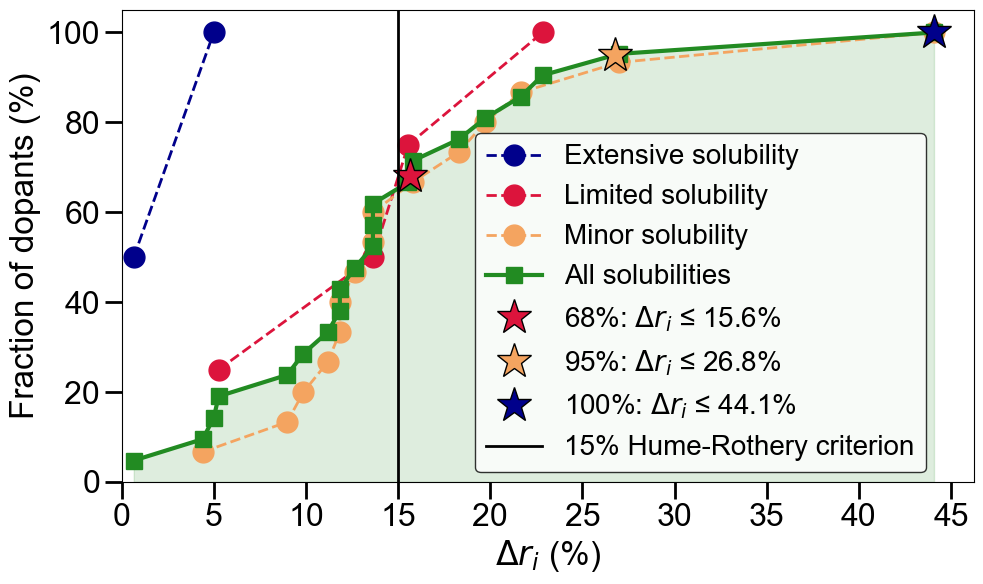

In [34]:
from pathlib import Path
FIGURES_DIR = Path('figures/h_r_rules')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fontsize = 24

# --- select solid‑solution dopants from DataFrame ---
mask_ss = data["element"].isin(solid_solutions_cand)
df_ss = data.loc[mask_ss].copy().reset_index(drop=True)

# --- attach region type (wide / small / narrow) ---
df_ss["region_type"] = df_ss["element"].map(solid_solutions_cand)

# --- absolute radius difference in % ---
df_ss["|Rule 1, difference, %|"] = np.abs(df_ss["Rule 1, difference, %"])

# --- plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

region_labels = {
    "wide":   "Extensive solubility",
    "small": "Limited solubility",
    "narrow": "Minor solubility",
}
colors = {
    "wide":  "darkblue",
    "small": "crimson",
    "narrow": "sandybrown",
}

# Store data for ALL regions combined
all_diffs = []
all_cumulative_percent = None
all_sorted_diffs = None

# Store narrow region data for sigma calculation
narrow_diffs = None
narrow_cumulative_percent = None
narrow_sorted_diffs = None

for region, label in region_labels.items():

    mask_region = df_ss["region_type"] == region
    diffs = df_ss.loc[mask_region, "|Rule 1, difference, %|"].values

    if len(diffs) == 0:
        continue

    # Collect all diffs for combined statistics
    all_diffs.extend(diffs)

    # Store narrow region diffs for statistical analysis
    if region == "narrow":
        narrow_diffs = diffs
        narrow_sorted_diffs = np.sort(diffs)
        cumulative_frac = np.arange(1, len(narrow_sorted_diffs) + 1) / len(narrow_sorted_diffs)
        narrow_cumulative_percent = cumulative_frac * 100

    sorted_diffs = np.sort(diffs)
    cumulative_frac = np.arange(1, len(sorted_diffs) + 1) / len(sorted_diffs)
    
    # Convert fraction to percent (0-100%)
    cumulative_percent = cumulative_frac * 100

    linestyle = "--" if region != "narrow" else "--"
    marker = "o" if region != "narrow" else "o"

    ax.plot(sorted_diffs, cumulative_percent,
            marker=marker, markersize=15, linestyle=linestyle,
            linewidth=2, color=colors[region],
            label=label)

# --- Calculate statistics for ALL regions combined ---
all_diffs = np.array(all_diffs)
all_sorted_diffs = np.sort(all_diffs)
all_cumulative_frac = np.arange(1, len(all_sorted_diffs) + 1) / len(all_sorted_diffs)
all_cumulative_percent = all_cumulative_frac * 100

# Plot ALL regions combined curve
ax.plot(all_sorted_diffs, all_cumulative_percent,
        marker='s', markersize=12, linestyle='-',
        linewidth=3, color='forestgreen', alpha=1.0,
        label='All solubilities')

# --- Hatch the area BELOW the ALL solubilities curve (entire area) ---
ax.fill_between(all_sorted_diffs, 0, all_cumulative_percent, 
                alpha=0.15, color='forestgreen',)

# --- Statistics for ALL regions ---
mean_all = np.mean(all_diffs)
std_all = np.std(all_diffs, ddof=1)
median_all = np.median(all_diffs)

# Find X-values at specific Y positions (68%, 95%, 99.7%) for ALL data
def find_x_at_percentile(pct, sorted_diffs, cum_percent):
    """Find x-value at given cumulative percentile"""
    if pct <= cum_percent[0]:
        return sorted_diffs[0]
    if pct >= cum_percent[-1]:
        return sorted_diffs[-1]
    idx = np.searchsorted(cum_percent, pct)
    if idx == 0:
        return sorted_diffs[0]
    x1, x2 = sorted_diffs[idx-1], sorted_diffs[idx]
    y1, y2 = cum_percent[idx-1], cum_percent[idx]
    if y2 == y1:
        return x1
    t = (pct - y1) / (y2 - y1)
    return x1 + t * (x2 - x1)

x_at_68_all = find_x_at_percentile(68, all_sorted_diffs, all_cumulative_percent)
x_at_95_all = find_x_at_percentile(95, all_sorted_diffs, all_cumulative_percent)
x_at_997_all = find_x_at_percentile(100.0, all_sorted_diffs, all_cumulative_percent)

# --- Plot stars for ALL regions combined ---
ax.plot(x_at_68_all, 68, '*', color='crimson', markersize=26,
        markeredgecolor='black', markeredgewidth=1,
        label=fr'68%: $\Delta r_i$ ≤ {x_at_68_all:.1f}%')
ax.plot(x_at_95_all, 95, '*', color='sandybrown', markersize=26,
        markeredgecolor='black', markeredgewidth=1,
        label=fr'95%: $\Delta r_i$ ≤ {x_at_95_all:.1f}%')
ax.plot(x_at_997_all, 100.0, '*', color='darkblue', markersize=26,
        markeredgecolor='black', markeredgewidth=1,
        label=fr'100%: $\Delta r_i$ ≤ {x_at_997_all:.1f}%')

# --- Hume–Rothery 15% reference line ---
ax.axvline(x=15.0, color="k", linestyle="-", linewidth=2, label="15% Hume-Rothery criterion")

# --- Labels and styling ---
ax.set_xlabel(r"$\Delta r_i$ (%)", fontsize=fontsize)
ax.set_ylabel("Fraction of dopants (%)", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-1)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-3)

ax.set_xlim(0, None)
ax.set_ylim(0, 105)

ax.tick_params(axis='both', which='major', length=12, width=2.0, labelsize=fontsize-1, colors='black')
ax.tick_params(axis='both', which='minor', length=6, width=1.0, labelsize=fontsize-3)
ax.locator_params(axis='x', nbins=10)  
ax.locator_params(axis='y', nbins=8)  

ax.legend(fontsize=fontsize-4, loc=(0.415, 0.02), ncol=1, edgecolor="black")

plt.tight_layout()
plt.show()

# Save figures
fig.savefig(str(FIGURES_DIR / 'hr_rule_1.pdf'), dpi=600, bbox_inches='tight')
fig.savefig(str(FIGURES_DIR / 'hr_rule_1.png'), dpi=600, bbox_inches='tight')



In [35]:
# PRINT COMPREHENSIVE STATISTICS
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL ANALYSIS - ALL REGIONS COMBINED")
print("="*80)
print(f"Total number of dopants (all regions): {len(all_diffs)}")
print(f"\nDescriptive statistics (|Δr|, %):")
print(f"  Mean: {mean_all:.2f}%")
print(f"  Median: {median_all:.2f}%")
print(f"  Standard deviation: {std_all:.2f}%")
print(f"  Min: {np.min(all_diffs):.2f}%")
print(f"  Max: {np.max(all_diffs):.2f}%")

print(f"\nPercentile thresholds for ALL regions:")
print(f"  68% of ALL dopants have |Δr| ≤ {x_at_68_all:.2f}%")
print(f"  95% of ALL dopants have |Δr| ≤ {x_at_95_all:.2f}%")
print(f"  99.7% of ALL dopants have |Δr| ≤ {x_at_997_all:.2f}%")

# Compare with classical Hume-Rothery
fraction_below_15_all = np.sum(all_diffs <= 15) / len(all_diffs) * 100
print(f"\nClassical Hume-Rothery criterion (15%):")
print(f"  {fraction_below_15_all:.1f}% of ALL dopants fall below 15%")




STATISTICAL ANALYSIS - ALL REGIONS COMBINED
Total number of dopants (all regions): 21

Descriptive statistics (|Δr|, %):
  Mean: 14.64%
  Median: 13.64%
  Standard deviation: 9.35%
  Min: 0.66%
  Max: 44.08%

Percentile thresholds for ALL regions:
  68% of ALL dopants have |Δr| ≤ 15.62%
  95% of ALL dopants have |Δr| ≤ 26.77%
  99.7% of ALL dopants have |Δr| ≤ 44.08%

Classical Hume-Rothery criterion (15%):
  61.9% of ALL dopants fall below 15%


## Rule 2


In [36]:
mask_ss = data["element"].isin(solid_solutions_cand.keys())
df_ss = data.loc[mask_ss].copy().reset_index(drop=True)

N_total = len(df_ss)



In [37]:
df_ss.head(30)

,element,Z,r_atomic_pm,crystal,valency,chi,"Rule 1, logic","Rule 1, difference, pm","Rule 1, difference, %","Rule 2, logic","Rule 3, logic","Rule 3, valency difference, unit","Rule 3, valency of dopant is higher, logic","Rule 4, logic","Rule 4, difference, Pauling scale","Rule 4, %"
0,B,5,85,beta_rhombohedral,3,2.04,False,67,44.078947,False,False,2,True,False,1.06,51.960784
1,Na,11,186,bcc,1,0.93,True,-34,-18.279570,True,True,0,False,True,0.05,5.102041
2,Mg,12,160,hcp,2,1.31,True,-8,-5.000000,False,False,1,True,True,0.33,25.190840
3,Si,14,111,diamond,4,1.90,False,41,26.973684,False,False,3,True,False,0.92,48.421053
4,Ca,20,197,fcc,2,1.00,True,-45,-22.842640,False,False,1,True,True,0.02,2.000000
5,Cu,29,128,fcc,1,1.90,False,24,15.789474,False,True,0,False,False,0.92,48.421053
6,Zn,30,134,hcp,2,1.65,True,18,11.842105,False,False,1,True,False,0.67,40.606061
7,Ga,31,135,ortho,3,1.81,True,17,11.184211,False,False,2,True,False,0.83,45.856354
8,Ge,32,122,diamond,4,2.01,False,30,19.736842,False,False,3,True,False,1.03,51.243781
9,Y,39,180,hcp,3,1.22,True,-28,-15.555556,False,False,2,True,True,0.24,19.672131


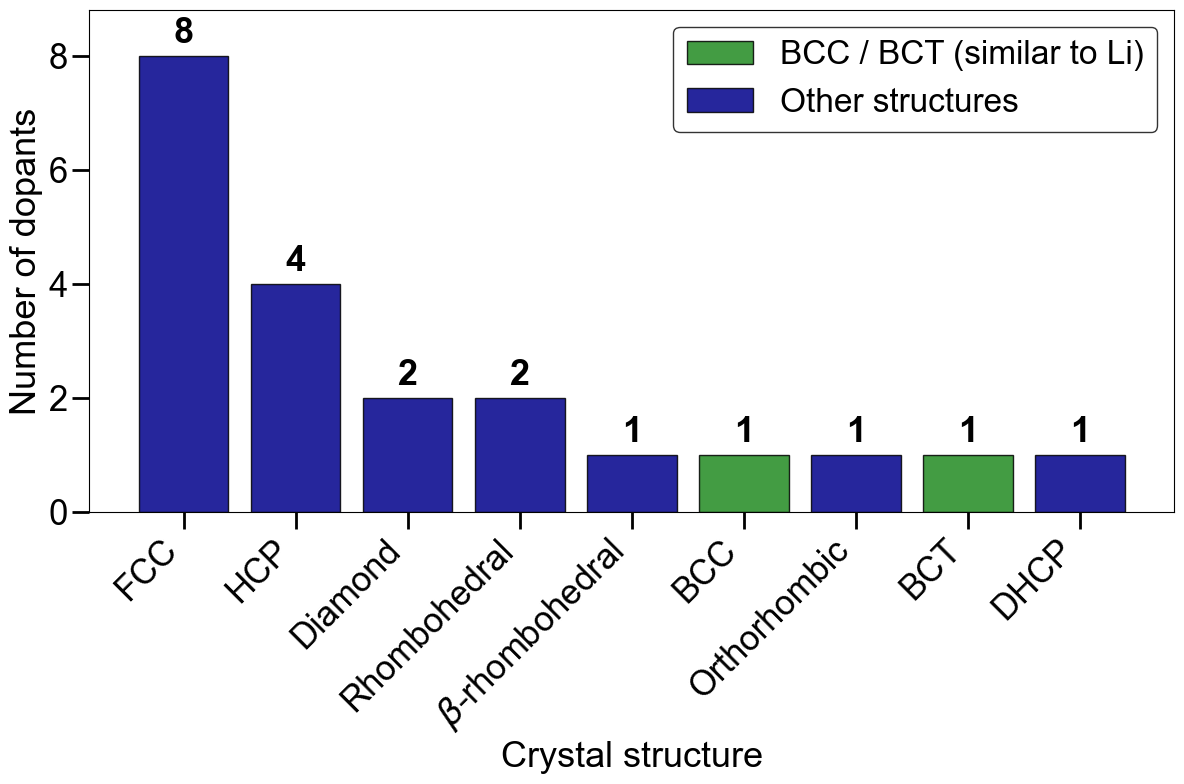

In [38]:
from pathlib import Path
FIGURES_DIR = Path('figures/h_r_rules')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fontsize = 26

# --- Additional visualization: Distribution of crystal structures ---
fig, ax2 = plt.subplots(figsize=(12, 8))

structure_counts = df_ss['crystal'].value_counts()

mapping = {
    "fcc": "FCC",
    "hcp": "HCP",
    "rhombo": "Rhombohedral",
    "tetra": "BCT",  # assuming tetra → body‑centered tetragonal (BCT)
    "beta_rhombohedral": r"$\beta$-rhombohedral",
    "ortho": "Orthorhombic",
    "bcc": "BCC",
    "diamond": "Diamond",
    "dhcp": "DHCP",
}

structure_counts.index = structure_counts.index.map(mapping)

# Define colors: green for BCC and BCT, blue for others
colors = []
for idx in structure_counts.index:
    if idx in ["BCC", "BCT"]:
        colors.append('forestgreen')
    else:
        colors.append('darkblue')

bars2 = ax2.bar(range(len(structure_counts)), structure_counts.values, color=colors, 
                edgecolor='black', alpha=0.85)

ax2.set_xticks(range(len(structure_counts)))
ax2.set_xticklabels(structure_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Number of dopants', fontsize=fontsize)
ax2.set_xlabel('Crystal structure', fontsize=fontsize)
# ax2.set_title('Distribution of crystal structures among solid-solution dopants', fontsize=13)
ax2.tick_params(axis='both', which='major', labelsize=fontsize-1)
ax2.tick_params(axis='both', which='minor', labelsize=fontsize-3)

# Add value labels on bars
for bar, count in zip(bars2, structure_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
             f"{str(count)}", ha='center', va='bottom', fontweight='bold', fontsize=fontsize)

ax2.set_ylim([0, 8.8])

# Add legend
legend_elements = [
    Patch(facecolor='forestgreen', edgecolor='black', alpha=0.85, label='BCC / BCT (similar to Li)'),
    Patch(facecolor='darkblue', edgecolor='black', alpha=0.85, label='Other structures')
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=fontsize-2, edgecolor="black")

ax2.tick_params(axis='both', which='major', length=12, width=2.0, labelsize=fontsize-1, colors='black')
ax2.tick_params(axis='both', which='minor', length=6, width=1.0, labelsize=fontsize-3)
ax2.locator_params(axis='x', nbins=10)  
ax2.locator_params(axis='y', nbins=8)  

plt.tight_layout()
plt.show()

fig.savefig(str(FIGURES_DIR / 'hr_rule_2.pdf'), dpi=600, bbox_inches='tight')
fig.savefig(str(FIGURES_DIR / 'hr_rule_2.png'), dpi=600, bbox_inches='tight')



## Rule 3

In [39]:
data['valency']

0     1
1     1
2     2
3     3
4     1
5     2
6     3
7     4
8     1
9     2
10    3
11    4
12    5
13    3
14    2
15    2
16    2
17    2
18    1
19    2
20    3
21    4
22    5
23    1
24    2
25    3
26    4
27    5
28    6
29    7
30    3
31    3
32    2
33    1
34    2
35    3
36    4
37    5
38    1
39    2
40    3
41    3
42    3
43    3
44    3
45    2
46    3
47    3
48    3
49    3
50    3
51    3
52    2
53    3
54    4
55    5
56    6
57    7
58    4
59    3
60    2
61    1
62    2
63    5
Name: valency, dtype: int64

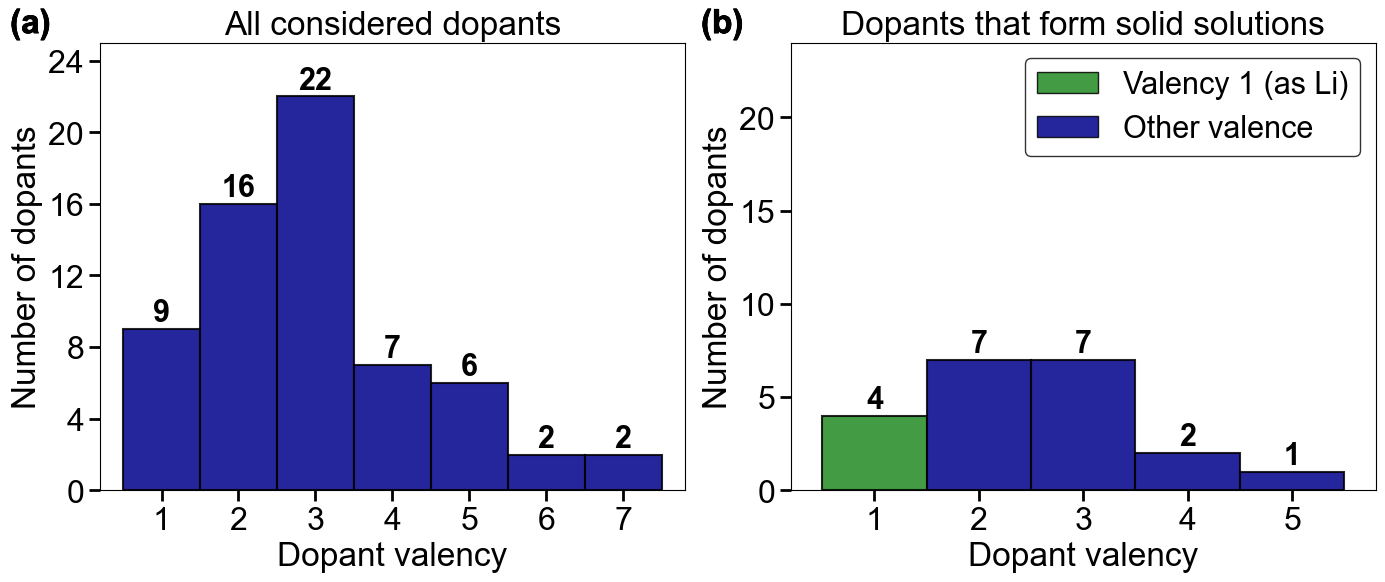

In [40]:
from pathlib import Path
FIGURES_DIR = Path('figures/h_r_rules')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fontsize = 24
shift = 0.5

fig, (ax, ax2) = plt.subplots(ncols=2, figsize=(14, 6))

# If that is true, the valence column is:
valence_col = "valency"

# Get unique valencies and sort them
unique_valencies = sorted(data[valence_col].unique())

# --- histogram of dopant valence ---
# Use integer bins centered on valency values
counts, bins, patches = ax.hist(data[valence_col],
    bins=np.arange(min(unique_valencies)-0.5, max(unique_valencies)+1.5, 1),
    edgecolor="black",
    alpha=0.85,
    color="darkblue",
    linewidth=1.5,
)

# Color ONLY the first bin in green
if len(patches) > 0:
    patches[0].set_facecolor('darkblue')

    

# Add count labels on top of each bar
for i, (count, val) in enumerate(zip(counts, unique_valencies)):
    if count > 0:
        ax.text(val, count + 0.1, f"{str(int(count))}", 
                ha='center', va='bottom', fontsize=fontsize-2, fontweight='bold')

ax.set_xlabel("Dopant valency", fontsize=fontsize)
ax.set_ylabel("Number of dopants", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-4)

# Set x-ticks to integer valency values
ax.set_xticks(unique_valencies)
ax.set_xticklabels([str(v) for v in unique_valencies])

# Set y-axis to integer ticks
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.locator_params(axis='y', nbins=8)

# Add light grid for better readability
# ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Set x-axis limits with some padding
ax.set_xlim(min(unique_valencies)-0.8, max(unique_valencies)+0.8)
ax.set_ylim([0, 24])

# legend_elements = [
    # Patch(facecolor='forestgreen', edgecolor='black', alpha=0.85, ),
    # Patch(facecolor='forestgreen', edgecolor='black', alpha=0.85, label='Valency 1 (as Li)'),
    # Patch(facecolor='darkblue', edgecolor='black', alpha=0.85, label='Other valence')
# ]
# ax.legend(handles=legend_elements, loc='upper right', fontsize=fontsize-2, edgecolor="black")

ax.tick_params(axis='both', length=6)  # Length in points (default is ~4)
ax.tick_params(axis='both', width=1.5)  # Thickness in points (default is ~1)


# RIGHT plot

# If that is true, the valence column is:
valence_col = "valency"

# Filter data to only include dopants that form solid solutions
# Assuming your data has a 'dopant' column with element symbols
data_filtered = data[data['element'].isin(solid_solutions_cand.keys())]

# Get unique valencies and sort them from filtered data
unique_valencies = sorted(data_filtered[valence_col].unique())

# --- histogram of dopant valence (only solid solution formers) ---
# Use integer bins centered on valency values
counts, bins, patches = ax2.hist(data_filtered[valence_col],
    bins=np.arange(min(unique_valencies)-0.5, max(unique_valencies)+1.5, 1),
    edgecolor="black",
    alpha=0.85,
    color="darkblue",
    linewidth=1.5,
)

# Color ONLY the first bin in green
if len(patches) > 0:
    patches[0].set_facecolor('forestgreen')

# Add count labels on top of each bar
for i, (count, val) in enumerate(zip(counts, unique_valencies)):
    if count > 0:
        ax2.text(val, count + 0.1, f"{str(int(count))}", 
                ha='center', va='bottom', fontsize=fontsize-2, fontweight='bold')

ax2.set_xlabel("Dopant valency", fontsize=fontsize)
ax2.set_ylabel("Number of dopants", fontsize=fontsize)
ax2.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax2.tick_params(axis='both', which='minor', labelsize=fontsize-4)

# Set x-ticks to integer valency values
ax2.set_xticks(unique_valencies)
ax2.set_xticklabels([str(v) for v in unique_valencies])

# Set y-axis to integer ticks
# ax2.yaxis.set_major_locator(plt.Max2NLocator(integer=True))
ax2.locator_params(axis='y', nbins=8)

# Set x-axis limits with some padding
ax2.set_xlim(min(unique_valencies)-0.8, max(unique_valencies)+0.8)
ax2.set_ylim([0, 24])

legend_elements = [
    Patch(facecolor='forestgreen', edgecolor='black', alpha=0.85, label='Valency 1 (as Li)'),
    Patch(facecolor='darkblue', edgecolor='black', alpha=0.85, label='Other valence')
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=fontsize-2, edgecolor="black")

ax2.tick_params(axis='both', length=6)
ax2.tick_params(axis='both', width=1.5)

ax.set_title("All considered dopants", fontsize=fontsize)
ax2.set_title("Dopants that form solid solutions", fontsize=fontsize)


ax.set_ylim([0,25])

ax.text(-0.154, 1.075, f'(a)', transform=ax.transAxes, ha='left', va='top', fontsize=fontsize, fontweight='bold',
         path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=0.5, foreground='white'),
                      plt.matplotlib.patheffects.withStroke(linewidth=0.5, foreground='black')])
ax2.text(-0.154, 1.075, f'(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=fontsize, fontweight='bold',
         path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=0.5, foreground='white'),
                      plt.matplotlib.patheffects.withStroke(linewidth=0.5, foreground='black')])

ax.tick_params(axis='both', which='major', length=8, width=2.0, labelsize=fontsize-1, colors='black')
ax.tick_params(axis='both', which='minor', length=6, width=1.0, labelsize=fontsize-3)
ax.locator_params(axis='x', nbins=10)  
ax.locator_params(axis='y', nbins=8)  

ax2.tick_params(axis='both', which='major', length=8, width=2.0, labelsize=fontsize-1, colors='black')
ax2.tick_params(axis='both', which='minor', length=6, width=1.0, labelsize=fontsize-3)
ax2.locator_params(axis='x', nbins=10)  
ax2.locator_params(axis='y', nbins=8)  

fig.tight_layout()
plt.show()

# Save the figure (removed duplicate save line)
fig.savefig(str(FIGURES_DIR / 'hr_rule_3.pdf'), dpi=600, bbox_inches='tight')
fig.savefig(str(FIGURES_DIR / 'hr_rule_3.png'), dpi=600, bbox_inches='tight')



## Rule 4

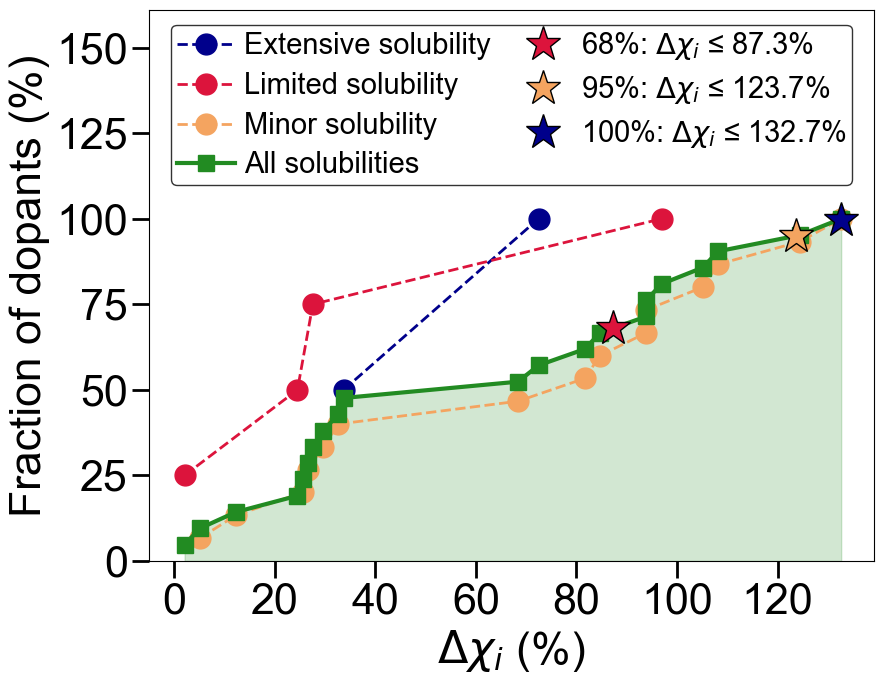

In [41]:
from pathlib import Path
FIGURES_DIR = Path('figures/h_r_rules')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fontsize = 32

# --- select solid‑solution dopants ---
mask_ss = data["element"].isin(solid_solutions_cand)
df_ss = data.loc[mask_ss].copy().reset_index(drop=True)

# --- attach region type (wide / small / narrow) ---
df_ss["region_type"] = df_ss["element"].map(solid_solutions_cand)

# --- Rule 4: absolute electronegativity difference in PERCENT (%) ---
# Li electronegativity is 0.98 (Pauling scale)
# Convert absolute difference to percentage: (|Δχ| / χ_Li) × 100%
li_electronegativity = 0.98  # Pauling scale

# Your column "Rule 4, difference, Pauling scale" is already the absolute difference
# Convert to percentage
df_ss["|Rule 4, difference, EN| (%)"] = (np.abs(df_ss["Rule 4, difference, Pauling scale"]) / li_electronegativity) * 100

# --- plotting ---
fig, ax = plt.subplots(figsize=(9, 7))

region_labels = {
    "wide":   "Extensive solubility",
    "small": "Limited solubility",
    "narrow": "Minor solubility",
}
colors = {
    "wide":   "darkblue",
    "small":  "crimson",
    "narrow": "sandybrown",
}

# Store data for ALL regions combined
all_diffs = []
all_cumulative_percent = None
all_sorted_diffs = None

# Store narrow region data for sigma calculation
narrow_diffs = None
narrow_cumulative_percent = None
narrow_sorted_diffs = None

for region, label in region_labels.items():

    mask_region = df_ss["region_type"] == region
    diffs = df_ss.loc[mask_region, "|Rule 4, difference, EN| (%)"].values

    if len(diffs) == 0:
        continue

    # Collect all diffs for combined statistics
    all_diffs.extend(diffs)

    # Store narrow region diffs for statistical analysis
    if region == "narrow":
        narrow_diffs = diffs
        narrow_sorted_diffs = np.sort(diffs)
        cumulative_frac = np.arange(1, len(narrow_sorted_diffs) + 1) / len(narrow_sorted_diffs)
        narrow_cumulative_percent = cumulative_frac * 100

    sorted_diffs = np.sort(diffs)
    cumulative_frac = np.arange(1, len(sorted_diffs) + 1) / len(sorted_diffs)
    cumulative_percent = cumulative_frac * 100  # in percent

    linestyle = "--" if region != "narrow" else "--"
    marker = "o" if region != "narrow" else "o"

    ax.plot(sorted_diffs, cumulative_percent,
            marker=marker, markersize=15, linestyle=linestyle,
            linewidth=2, color=colors[region],
            label=label)

# --- Calculate statistics for ALL regions combined ---
all_diffs = np.array(all_diffs)
all_sorted_diffs = np.sort(all_diffs)
all_cumulative_frac = np.arange(1, len(all_sorted_diffs) + 1) / len(all_sorted_diffs)
all_cumulative_percent = all_cumulative_frac * 100

# Plot ALL regions combined curve
ax.plot(all_sorted_diffs, all_cumulative_percent,
        marker='s', markersize=12, linestyle='-',
        linewidth=3, color='forestgreen', alpha=1.0,
        label='All solubilities')

# --- Hatching below the ALL REGIONS curve (not narrow region) ---
ax.fill_between(all_sorted_diffs, 0, all_cumulative_percent,
                alpha=0.2, color='forestgreen',)

# --- Statistics for ALL regions ---
mean_all = np.mean(all_diffs)
std_all = np.std(all_diffs, ddof=1)
median_all = np.median(all_diffs)

# Helper: find x at given y (percentile) on the curve
def find_x_at_percentile(pct, sorted_diffs, cum_percent):
    if pct <= cum_percent[0]:
        return sorted_diffs[0]
    if pct >= cum_percent[-1]:
        return sorted_diffs[-1]
    idx = np.searchsorted(cum_percent, pct)
    if idx == 0:
        return sorted_diffs[0]
    x1, x2 = sorted_diffs[idx-1], sorted_diffs[idx]
    y1, y2 = cum_percent[idx-1], cum_percent[idx]
    if y2 == y1:
        return x1
    t = (pct - y1) / (y2 - y1)
    return x1 + t * (x2 - x1)

# Find X-values at specific Y positions for ALL data
x_at_68_all = find_x_at_percentile(68, all_sorted_diffs, all_cumulative_percent)
x_at_95_all = find_x_at_percentile(95, all_sorted_diffs, all_cumulative_percent)
x_at_997_all = find_x_at_percentile(100, all_sorted_diffs, all_cumulative_percent)

# --- Process narrow region (without hatching) ---
if narrow_diffs is not None and len(narrow_diffs) > 0:
    # --- statistics for narrow/limited region (ΔEN in %) ---
    mean_narrow = np.mean(narrow_diffs)
    std_narrow = np.std(narrow_diffs, ddof=1)
    median_narrow = np.median(narrow_diffs)

    # Find X-values at specific Y positions for narrow region
    x_at_68_narrow = find_x_at_percentile(68, narrow_sorted_diffs, narrow_cumulative_percent)
    x_at_95_narrow = find_x_at_percentile(95, narrow_sorted_diffs, narrow_cumulative_percent)
    x_at_997_narrow = find_x_at_percentile(99.7, narrow_sorted_diffs, narrow_cumulative_percent)

    # Plot stars for narrow region
    # ax.plot(x_at_68_narrow, 68, '*', color='crimson', markersize=26,
    #         markeredgecolor='black', markeredgewidth=1,
    #         label=f'Narrow: 68% (Δχ ≤ {x_at_68_narrow:.1f}%)')
    # ax.plot(x_at_95_narrow, 95, '*', color='darkblue', markersize=26,
    #         markeredgecolor='black', markeredgewidth=1,
    #         label=f'Narrow: 95% (Δχ ≤ {x_at_95_narrow:.1f}%)')
    # ax.plot(x_at_997_narrow, 99.7, '*', color='forestgreen', markersize=26,
    #         markeredgecolor='black', markeredgewidth=1,
    #         label=f'Narrow: 99.7% (Δχ ≤ {x_at_997_narrow:.1f}%)')

# --- Plot stars for ALL regions combined ---
ax.plot(x_at_68_all, 68, '*', color='crimson', markersize=26,
        markeredgecolor='black', markeredgewidth=1,
        label=fr'68%: $\Delta \chi_i$ ≤ {x_at_68_all:.1f}%')
ax.plot(x_at_95_all, 95, '*', color='sandybrown', markersize=26,
        markeredgecolor='black', markeredgewidth=1,
        label=fr'95%: $\Delta \chi_i$ ≤ {x_at_95_all:.1f}%')
ax.plot(x_at_997_all, 99.7, '*', color='darkblue', markersize=26,
        markeredgecolor='black', markeredgewidth=1,
        label=fr'100%: $\Delta \chi_i$ ≤ {x_at_997_all:.1f}%')

# --- labels and styling ---
ax.set_xlabel(r"$\Delta \chi_i$ (%)", fontsize=fontsize)
ax.set_ylabel("Fraction of dopants (%)", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-4)
ax.locator_params(axis='y', nbins=8)
ax.locator_params(axis='x', nbins=6)
ax.tick_params(axis='both', length=12)  # Length in points
ax.tick_params(axis='both', width=2)    # Thickness in points

ax.set_xlim(-5, None)
ax.set_ylim(0, 161)

ax.legend(fontsize=fontsize-11, loc=9, ncol=2, edgecolor="black", 
          labelspacing=0.4, columnspacing=0.8, borderpad=0.2, handletextpad=0.3)

ax.tick_params(axis='both', which='major', length=12, width=2.0, labelsize=fontsize-1, colors='black')
ax.tick_params(axis='both', which='minor', length=6, width=1.0, labelsize=fontsize-3)
ax.locator_params(axis='x', nbins=10)  
ax.locator_params(axis='y', nbins=8)  

plt.tight_layout()
plt.show()

# Save figures
fig.savefig(str(FIGURES_DIR / 'hr_rule_4.pdf'), dpi=600, bbox_inches='tight')
fig.savefig(str(FIGURES_DIR / 'hr_rule_4.png'), dpi=600, bbox_inches='tight')



In [42]:
# ============================================================================
# PRINT STATISTICS
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL ANALYSIS - ALL REGIONS COMBINED (Rule 4: ΔEN in %)")
print("="*80)
print(f"Total number of dopants (all regions): {len(all_diffs)}")
print(f"Li electronegativity: {li_electronegativity} (Pauling)")
print(f"\nDescriptive statistics (|Δχ|/χ_Li × 100%, %):")
print(f"  Mean: {mean_all:.1f}%")
print(f"  Median: {median_all:.1f}%")
print(f"  Standard deviation: {std_all:.1f}%")
print(f"  Min: {np.min(all_diffs):.1f}%")
print(f"  Max: {np.max(all_diffs):.1f}%")

print(f"\nPercentile thresholds for ALL regions:")
print(f"  68% of ALL dopants have Δχ ≤ {x_at_68_all:.1f}%")
print(f"  95% of ALL dopants have Δχ ≤ {x_at_95_all:.1f}%")
print(f"  99.7% of ALL dopants have Δχ ≤ {x_at_997_all:.1f}%")

# Classical Hume-Rothery threshold
classical_threshold = (0.4 / li_electronegativity) * 100
fraction_below_classical_all = np.sum(all_diffs <= classical_threshold) / len(all_diffs) * 100
print(f"\nClassical Hume-Rothery threshold (Δχ = 0.4 Pauling): {classical_threshold:.1f}%")
print(f"  → {fraction_below_classical_all:.1f}% of ALL dopants fall below this threshold")

print("\n" + "="*80)
print("STATISTICAL ANALYSIS - NARROW REGION ONLY (Rule 4: ΔEN in %)")
print("="*80)
if narrow_diffs is not None:
    print(f"Number of narrow/limited dopants: {len(narrow_diffs)}")
    print(f"\nDescriptive statistics (|Δχ|/χ_Li × 100%, %):")
    print(f"  Mean: {mean_narrow:.1f}%")
    print(f"  Median: {median_narrow:.1f}%")
    print(f"  Standard deviation: {std_narrow:.1f}%")
    print(f"  Min: {np.min(narrow_diffs):.1f}%")
    print(f"  Max: {np.max(narrow_diffs):.1f}%")
    
    print(f"\nPercentile thresholds for NARROW region:")
    print(f"  68% of narrow dopants have Δχ ≤ {x_at_68_narrow:.1f}%")
    print(f"  95% of narrow dopants have Δχ ≤ {x_at_95_narrow:.1f}%")
    print(f"  99.7% of narrow dopants have Δχ ≤ {x_at_997_narrow:.1f}%")
    
    fraction_below_classical_narrow = np.sum(narrow_diffs <= classical_threshold) / len(narrow_diffs) * 100
    print(f"\nClassical Hume-Rothery threshold (Δχ = 0.4 Pauling): {classical_threshold:.1f}%")
    print(f"  → {fraction_below_classical_narrow:.1f}% of narrow dopants fall below this threshold")

print("\n" + "="*80)
print("COMPARISON: ALL REGIONS vs NARROW REGION")
print("="*80)
print(f"{'Metric':<35} {'All Regions':<20} {'Narrow Region':<20}")
print("-"*75)
print(f"{'Mean Δχ (%)':<35} {mean_all:<20.1f} {mean_narrow:<20.1f}")
print(f"{'Median Δχ (%)':<35} {median_all:<20.1f} {median_narrow:<20.1f}")
print(f"{'Std Dev Δχ (%)':<35} {std_all:<20.1f} {std_narrow:<20.1f}")
print(f"{'68% threshold Δχ (%)':<35} {x_at_68_all:<20.1f} {x_at_68_narrow:<20.1f}")
print(f"{'95% threshold Δχ (%)':<35} {x_at_95_all:<20.1f} {x_at_95_narrow:<20.1f}")
print(f"{'99.7% threshold Δχ (%)':<35} {x_at_997_all:<20.1f} {x_at_997_narrow:<20.1f}")
print(f"{'% below 0.4 Pauling':<35} {fraction_below_classical_all:<20.1f} {fraction_below_classical_narrow:<20.1f}")



STATISTICAL ANALYSIS - ALL REGIONS COMBINED (Rule 4: ΔEN in %)
Total number of dopants (all regions): 21
Li electronegativity: 0.98 (Pauling)

Descriptive statistics (|Δχ|/χ_Li × 100%, %):
  Mean: 61.0%
  Median: 68.4%
  Standard deviation: 41.5%
  Min: 2.0%
  Max: 132.7%

Percentile thresholds for ALL regions:
  68% of ALL dopants have Δχ ≤ 87.3%
  95% of ALL dopants have Δχ ≤ 123.7%
  99.7% of ALL dopants have Δχ ≤ 132.7%

Classical Hume-Rothery threshold (Δχ = 0.4 Pauling): 40.8%
  → 47.6% of ALL dopants fall below this threshold

STATISTICAL ANALYSIS - NARROW REGION ONLY (Rule 4: ΔEN in %)
Number of narrow/limited dopants: 15

Descriptive statistics (|Δχ|/χ_Li × 100%, %):
  Mean: 68.3%
  Median: 81.6%
  Standard deviation: 42.7%
  Min: 5.1%
  Max: 132.7%

Percentile thresholds for NARROW region:
  68% of narrow dopants have Δχ ≤ 93.9%
  95% of narrow dopants have Δχ ≤ 126.5%
  99.7% of narrow dopants have Δχ ≤ 132.3%

Classical Hume-Rothery threshold (Δχ = 0.4 Pauling): 40.8%
  → 